# Equilibrium LOB Shape $\mathcal{D}(a)$ — Bertrand MFG Model

## Closed-Form Solution under Uniform $F$ and Uniform $G$

---

**Goal.** Derive and plot the equilibrium ask-side depth profile $\mathcal{D}(a)$ for the Polymarket BTC binary option, in the special case where buyer valuations $v \sim \text{Uniform}[0,1]$ and LP discount rates $r \sim \text{Uniform}[r_{\min}, r_{\max}]$.

## 1. Setup and Specialisation to Uniform Distributions

### 1.1 Buyer Side

$v \sim \text{Uniform}[0,1]$:
$$F(a) = a, \quad f(a) = 1, \quad 1-F(a) = 1-a.$$

Market order flow at ask $a$:
$$\phi(a) = \alpha[1 - F(a)] = \alpha(1-a).$$

### 1.2 LP Side

$r \sim \text{Uniform}[r_{\min}, r_{\max}]$:
$$g(r) = \frac{1}{\Delta r}, \quad \Delta r \equiv r_{\max} - r_{\min}.$$

### 1.3 Key Derived Objects

**Fill rate per unit depth:**
$$\mu(a) = \frac{\phi(a)}{\mathcal{D}(a)} = \frac{\alpha(1-a)}{\mathcal{D}(a)}.$$

**Optimal replenishment** (substituting $f=1$, $1-F=1-a$):
$$\delta^*(a) = \frac{(a-c)f(a) - [1-F(a)]}{\eta \cdot f(a)} = \frac{2a - 1 - c}{\eta}.$$

This is positive iff $a > a_{\min} \equiv \frac{1+c}{2}$. Below $a_{\min}$, no LP finds it profitable to post.

**Auxiliary function** $H(a)$ (appears in $r(a) = H(a)/\mathcal{D}(a)$):
$$H(a) \equiv \frac{[1-F(a)]\,\phi(a)}{(a-c)f(a) - [1-F(a)]} = \frac{\alpha(1-a)^2}{2a - 1 - c}.$$

Note: $H(a) \to +\infty$ as $a \to a_{\min}^+$ and $H(a) \to 0$ as $a \to 1^-$.

## 2. Deriving the ODE for $\mathcal{D}(a)$

### 2.1 The Equilibrium Equation

Depth at price level $a$ equals the mass of LPs posting there $\times$ average depth per LP:
$$\mathcal{D}(a) = \frac{N_{LP}\,\delta^*(a)}{2} \cdot g(r(a)) \cdot |r'(a)|.$$

Under uniform $G$, $g(r) = 1/\Delta r$ is constant:
$$\mathcal{D}(a) = \frac{N_{LP}\,\delta^*(a)}{2\,\Delta r} \cdot |r'(a)|. \tag{EQ}$$

### 2.2 Substituting $r = H/\mathcal{D}$

Differentiating $r(a) = H(a)/\mathcal{D}(a)$:
$$r'(a) = \frac{H'\,\mathcal{D} - H\,\mathcal{D}'}{\mathcal{D}^2}.$$

Substituting into (EQ) and solving for $\mathcal{D}'$:

$$\boxed{\mathcal{D}' = \frac{H'}{H}\,\mathcal{D} - \frac{2\,\Delta r}{N_{LP}\,\delta^*(a)\,H(a)}\,\mathcal{D}^3.} \tag{Bernoulli ODE}$$

This is a **Bernoulli equation** of order 3 in $\mathcal{D}$.

## 3. Solving the Bernoulli ODE

### 3.1 Reduction to Linear ODE

Substitute $w(a) = \mathcal{D}(a)^{-2}$, so $w' = -2\,\mathcal{D}^{-3}\,\mathcal{D}'$:
$$w' + \frac{2H'(a)}{H(a)}\,w = \frac{4\,\Delta r}{N_{LP}\,\delta^*(a)\,H(a)}.$$

### 3.2 Integrating Factor Solution

Integrating factor: $H(a)^2$. Multiplying through:
$$\frac{d}{da}\bigl[H(a)^2\,w(a)\bigr] = \frac{4\,\Delta r\,H(a)}{N_{LP}\,\delta^*(a)}.$$

### 3.3 Boundary Condition

At $a_0$ (left edge): $r(a_0) = r_{\min}$, so $\mathcal{D}(a_0) = H(a_0)/r_{\min}$ and $H(a_0)^2\,w(a_0) = r_{\min}^2$.

### 3.4 Closed-Form Solution

$$\boxed{\mathcal{D}(a) = \frac{H(a)}{\sqrt{r_{\min}^2 + \Phi(a)}}, \qquad r(a) = \sqrt{r_{\min}^2 + \Phi(a)}} \tag{$\star$}$$

where $\Phi(a) \equiv \dfrac{4\,\Delta r}{N_{LP}} \displaystyle\int_{a_0}^{a} \frac{H(s)}{\delta^*(s)}\,ds$.

Book right edge: $a_{\max}$ satisfies $\Phi(a_{\max}) = r_{\max}^2 - r_{\min}^2$.

## 4. Closed-Form Antiderivative

The integrand $\frac{H(s)}{\delta^*(s)} = \frac{\alpha\,\eta\,(1-s)^2}{(2s-1-c)^2}$ has antiderivative:

$$J(s) = \frac{1}{8}\left[-\frac{(1-c)^2}{2s-1-c} - 2(1-c)\ln(2s-1-c) + (2s-1-c)\right]$$

(via $\sigma = 2s-1-c$, $1-s = \frac{(1-c)-\sigma}{2}$, partial fractions).

So $\Phi(a) = \frac{4\alpha\eta\Delta r}{N_{LP}}\bigl[J(a) - J(a_0)\bigr]$ — **fully explicit**, no quadrature needed.

## 5. Book Concentration Phenomenon

Near $a_{\min}$: $H(a)/\delta^*(a) \sim \alpha\eta(1-a_{\min})^2 (a - a_{\min})^{-2}$.

This causes $\Phi(a)$ to grow like $(a-a_{\min})^{-1}$, making $r(a)$ shoot up rapidly.

**Economic interpretation:** Under uniform beliefs, the LOB concentrates near $a_{\min}$ — patient LPs cluster just above the minimum viable ask, and the discount rate $r(a)$ saturates quickly. The book is **narrow but deep** near $a_{\min}$.

This concentration weakens under:
- **Pareto $G$**: heavy tails spread depth over wider ask range
- **Non-uniform $F$**: if $f(a_{\min})$ is small, the singularity softens
- **Large $N_{LP}/(\alpha\eta)$**: slower $\Phi$ growth $\Rightarrow$ wider book

---

# Implementation

In [1]:
import numpy as np
from scipy.optimize import brentq
from scipy.integrate import solve_ivp, trapezoid
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.labelsize': 14, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'lines.linewidth': 2, 'figure.dpi': 120,
})

In [2]:
# ============================================================
# Core model functions (uniform F on [0,1])
# ============================================================

def delta_star(a, c, eta):
    """Optimal replenishment: delta*(a) = (2a - 1 - c) / eta."""
    return np.maximum((2*a - 1.0 - c) / eta, 0.0)

def H_func(a, alpha, c):
    """H(a) = alpha*(1-a)^2 / (2a - 1 - c)."""
    sigma = 2*a - 1.0 - c
    return np.where(sigma > 1e-15, alpha * (1.0 - a)**2 / sigma, np.inf)

def H_prime(a, alpha, c):
    """dH/da by quotient rule."""
    sigma = 2*a - 1.0 - c
    num = (1.0 - a)**2
    return alpha * (-2*(1.0-a)*sigma - 2*num) / sigma**2

def J_antideriv(s, c):
    """Antiderivative of (1-s)^2 / (2s-1-c)^2.
    J(s) = (1/8)*[-omega^2/sigma - 2*omega*ln(sigma) + sigma]
    where sigma = 2s-1-c, omega = 1-c.
    """
    sigma = 2*s - 1.0 - c
    omega = 1.0 - c
    return (1.0/8.0) * (-omega**2 / sigma - 2*omega*np.log(sigma) + sigma)

def Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r):
    """Cumulative integral Phi(a) using the closed-form antiderivative."""
    coeff = 4 * alpha * eta * Delta_r / N_LP
    return coeff * (J_antideriv(a, c) - J_antideriv(a0, c))

def D_closedform(a, a0, r_min, alpha, c, eta, N_LP, Delta_r):
    """Closed-form D(a) = H(a) / sqrt(r_min^2 + Phi(a))."""
    H = H_func(a, alpha, c)
    Ph = Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r)
    return H / np.sqrt(r_min**2 + Ph)

def r_closedform(a, a0, r_min, alpha, c, eta, N_LP, Delta_r):
    """r(a) = sqrt(r_min^2 + Phi(a))."""
    Ph = Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r)
    return np.sqrt(r_min**2 + Ph)

def find_book_boundaries(a_min, r_min, r_max, alpha, c, eta, N_LP, Delta_r, eps=0.005):
    """Find a0 and a_max for the book."""
    a0 = a_min + eps
    target = r_max**2 - r_min**2
    Phi_at_1 = Phi_exact(0.999, a0, alpha, c, eta, N_LP, Delta_r)
    if Phi_at_1 < target:
        r_max_eff = np.sqrt(r_min**2 + Phi_at_1)
        print(f'  Note: effective r_max = {r_max_eff:.4f} < nominal {r_max:.4f}')
        return a0, 0.999
    a_max = brentq(lambda a: Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r) - target,
                   a0 + 1e-8, 0.999, xtol=1e-12)
    return a0, a_max

def compute_lob(alpha_p, c_p, eta_p, N_LP_p, r_min_p, r_max_p, eps_p=0.005, n_pts=500):
    """Full equilibrium computation. Returns dict."""
    Dr = r_max_p - r_min_p
    am = (1 + c_p) / 2
    a0_p, amax_p = find_book_boundaries(am, r_min_p, r_max_p, alpha_p, c_p, eta_p, N_LP_p, Dr, eps_p)
    ag = np.linspace(a0_p + 1e-8, amax_p - 1e-8, n_pts)
    Dv = D_closedform(ag, a0_p, r_min_p, alpha_p, c_p, eta_p, N_LP_p, Dr)
    rv = r_closedform(ag, a0_p, r_min_p, alpha_p, c_p, eta_p, N_LP_p, Dr)
    return {'a': ag, 'D': Dv, 'r': rv, 'delta': delta_star(ag, c_p, eta_p),
            'mu': alpha_p*(1-ag)/Dv, 'a0': a0_p, 'a_max': amax_p, 'a_min': am,
            'total_depth': trapezoid(Dv, ag), 'book_width': amax_p - a0_p}

print('Core functions defined.')

Core functions defined.


## 6. Baseline Parameters

In [3]:
alpha = 10.0       # Buyer arrival rate
c     = 0.30       # LP cost basis
eta   = 5.0        # Convex carrying-cost coefficient
N_LP  = 50.0       # Mass of LPs
r_min = 0.05       # Most patient LP discount rate
r_max = 1.00       # Most impatient LP discount rate

Delta_r = r_max - r_min
a_min   = (1.0 + c) / 2.0
eps     = 0.005

a0, a_max = find_book_boundaries(a_min, r_min, r_max, alpha, c, eta, N_LP, Delta_r, eps)

print(f'a_min  = (1+c)/2 = {a_min:.4f}')
print(f'a0     = {a0:.6f}')
print(f'a_max  = {a_max:.6f}')
print(f'Width  = {(a_max-a0)*1e4:.2f} × 10⁻⁴')
print(f'r(a0)  = {r_closedform(a0,a0,r_min,alpha,c,eta,N_LP,Delta_r):.6f}  ✓ r_min={r_min}')
print(f'r(amax)= {r_closedform(a_max,a0,r_min,alpha,c,eta,N_LP,Delta_r):.6f}  ✓ r_max={r_max}')

a_min  = (1+c)/2 = 0.6500
a0     = 0.655000
a_max  = 0.655231
Width  = 2.31 × 10⁻⁴
r(a0)  = 0.050000  ✓ r_min=0.05
r(amax)= 1.000000  ✓ r_max=1.0


## 7. Equilibrium LOB Shape — Main Plot

C:\Users\filip\AppData\Local\Temp\ipykernel_38088\1543075274.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


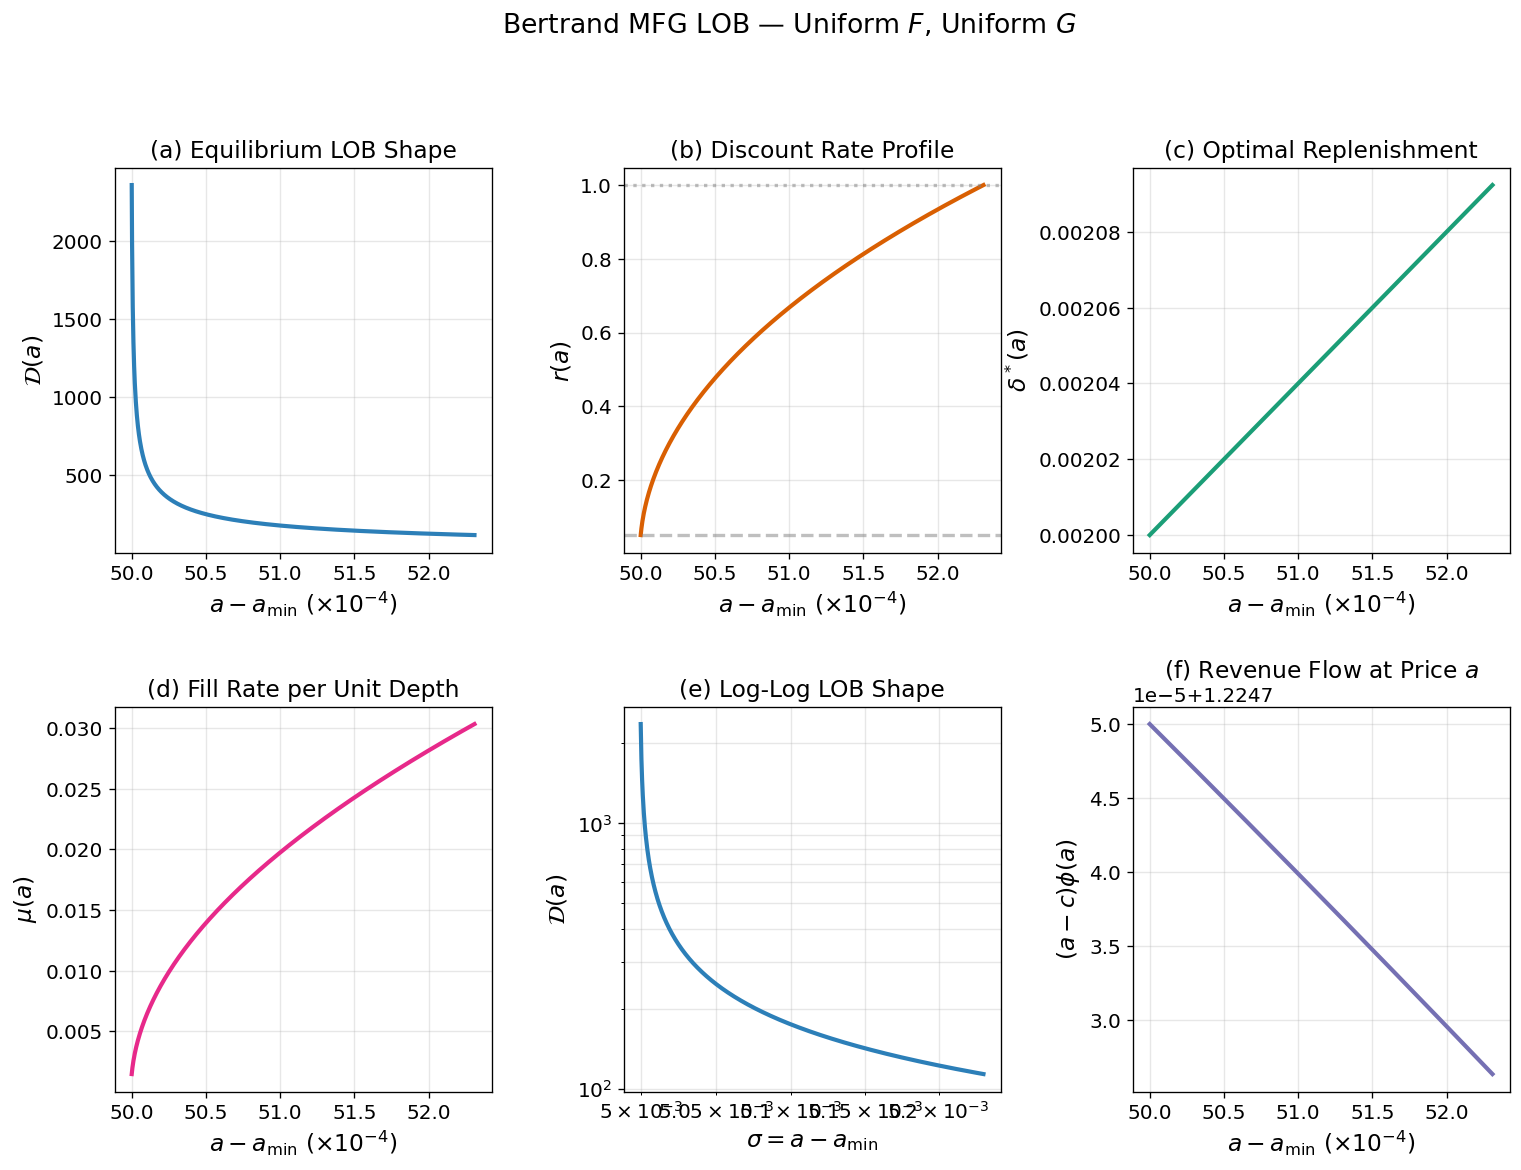


Total depth = 0.0508
D_max = 2359.2 at a = 0.655000


In [4]:
a_grid = np.linspace(a0 + 1e-8, a_max - 1e-8, 1000)
D_vals     = D_closedform(a_grid, a0, r_min, alpha, c, eta, N_LP, Delta_r)
r_vals     = r_closedform(a_grid, a0, r_min, alpha, c, eta, N_LP, Delta_r)
delta_vals = delta_star(a_grid, c, eta)
mu_vals    = alpha * (1 - a_grid) / D_vals
phi_vals   = alpha * (1 - a_grid)
sigma_grid = a_grid - a_min  # spread above a_min

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(sigma_grid*1e4, D_vals, color='#2c7fb8', lw=2.5)
ax1.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
ax1.set_ylabel(r'$\mathcal{D}(a)$')
ax1.set_title('(a) Equilibrium LOB Shape')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(sigma_grid*1e4, r_vals, color='#d95f02', lw=2.5)
ax2.axhline(r_min, color='gray', ls='--', alpha=0.5)
ax2.axhline(r_max, color='gray', ls=':', alpha=0.5)
ax2.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
ax2.set_ylabel(r'$r(a)$')
ax2.set_title('(b) Discount Rate Profile')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(sigma_grid*1e4, delta_vals, color='#1b9e77', lw=2.5)
ax3.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
ax3.set_ylabel(r'$\delta^*(a)$')
ax3.set_title('(c) Optimal Replenishment')
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(sigma_grid*1e4, mu_vals, color='#e7298a', lw=2.5)
ax4.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
ax4.set_ylabel(r'$\mu(a)$')
ax4.set_title('(d) Fill Rate per Unit Depth')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
ax5.loglog(sigma_grid, D_vals, color='#2c7fb8', lw=2.5)
ax5.set_xlabel(r'$\sigma = a - a_{\min}$')
ax5.set_ylabel(r'$\mathcal{D}(a)$')
ax5.set_title('(e) Log-Log LOB Shape')
ax5.grid(True, alpha=0.3, which='both')

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(sigma_grid*1e4, (a_grid-c)*phi_vals, color='#7570b3', lw=2.5)
ax6.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
ax6.set_ylabel(r'$(a-c)\phi(a)$')
ax6.set_title('(f) Revenue Flow at Price $a$')
ax6.grid(True, alpha=0.3)

fig.suptitle(r'Bertrand MFG LOB — Uniform $F$, Uniform $G$', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

total_depth = trapezoid(D_vals, a_grid)
print(f'\nTotal depth = {total_depth:.4f}')
print(f'D_max = {np.max(D_vals):.1f} at a = {a_grid[np.argmax(D_vals)]:.6f}')

## 8. Cross-Validation: Closed-Form vs Numerical ODE

We verify (★) by solving the Bernoulli ODE directly with `solve_ivp` (DOP853, tol $= 10^{-12}$).

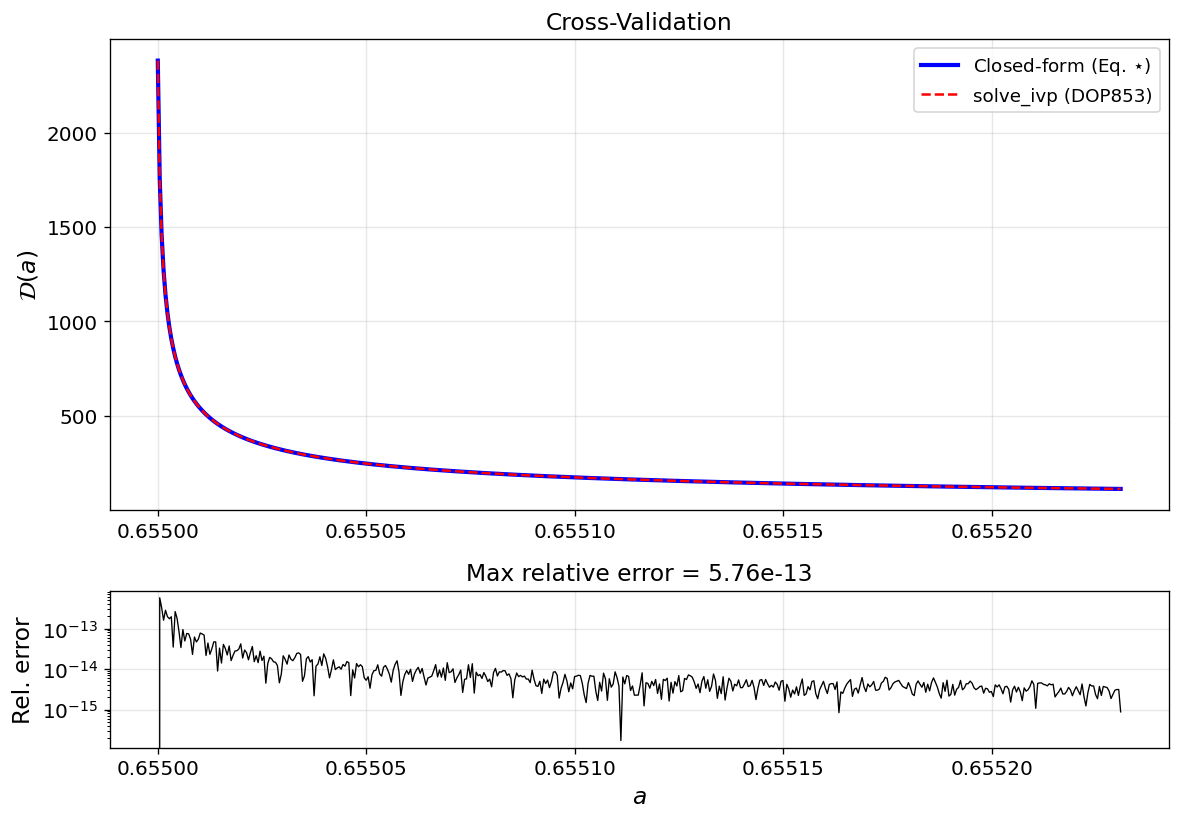

In [5]:
def bernoulli_rhs(a, D_vec):
    D = D_vec[0]
    if D < 1e-15: return [0.0]
    a_f = float(a)
    Hv = float(H_func(a_f, alpha, c))
    Hp = float(H_prime(a_f, alpha, c))
    ds = float(delta_star(a_f, c, eta))
    if ds < 1e-15: return [0.0]
    return [(Hp/Hv)*D - (2*Delta_r/(N_LP*ds*Hv))*D**3]

D0 = float(D_closedform(a0, a0, r_min, alpha, c, eta, N_LP, Delta_r))
sol = solve_ivp(bernoulli_rhs, [a0, a_max], [D0], method='DOP853',
                dense_output=True, rtol=1e-12, atol=1e-14,
                max_step=(a_max-a0)/500)

a_num = np.linspace(a0, a_max, 500)
D_num = sol.sol(a_num)[0]
D_cf  = D_closedform(a_num, a0, r_min, alpha, c, eta, N_LP, Delta_r)
rel_err = np.abs(D_num - D_cf) / (np.abs(D_cf) + 1e-20)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[3, 1])
ax1.plot(a_num, D_cf, 'b-', lw=2.5, label=r'Closed-form (Eq. $\star$)')
ax1.plot(a_num, D_num, 'r--', lw=1.5, label='solve_ivp (DOP853)')
ax1.set_ylabel(r'$\mathcal{D}(a)$'); ax1.set_title('Cross-Validation')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(a_num, rel_err, 'k-', lw=0.8)
ax2.set_xlabel('$a$'); ax2.set_ylabel('Rel. error')
ax2.set_title(f'Max relative error = {np.max(rel_err):.2e}')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Comparative Statics

N_LP=  20: width=0.90×10⁻⁴, total_depth=0.0201
N_LP=  50: width=2.31×10⁻⁴, total_depth=0.0508
N_LP= 100: width=4.84×10⁻⁴, total_depth=0.1033
N_LP= 200: width=10.75×10⁻⁴, total_depth=0.2140


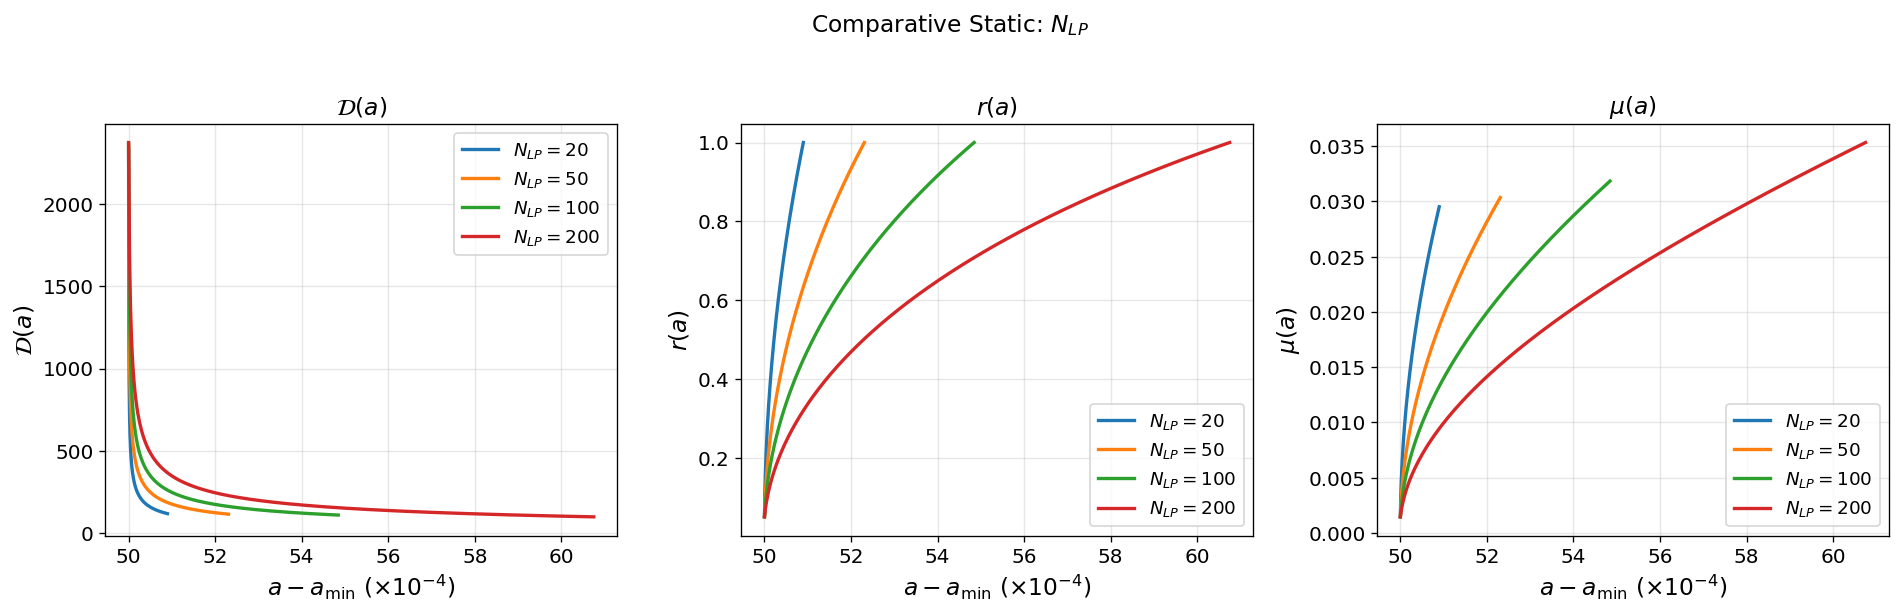

In [6]:
# === CS1: LP Mass N_LP ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for N_val in [20, 50, 100, 200]:
    res = compute_lob(alpha, c, eta, N_val, r_min, r_max)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'],  label=f'$N_{{LP}}={N_val}$')
    axes[1].plot(sig*1e4, res['r'],  label=f'$N_{{LP}}={N_val}$')
    axes[2].plot(sig*1e4, res['mu'], label=f'$N_{{LP}}={N_val}$')
    print(f'N_LP={N_val:>4d}: width={res["book_width"]*1e4:.2f}×10⁻⁴, '
          f'total_depth={res["total_depth"]:.4f}')

for i, (t, y) in enumerate([
    (r'$\mathcal{D}(a)$', r'$\mathcal{D}(a)$'),
    (r'$r(a)$', r'$r(a)$'), (r'$\mu(a)$', r'$\mu(a)$')]):
    axes[i].set_title(t); axes[i].set_ylabel(y)
    axes[i].set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $N_{LP}$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

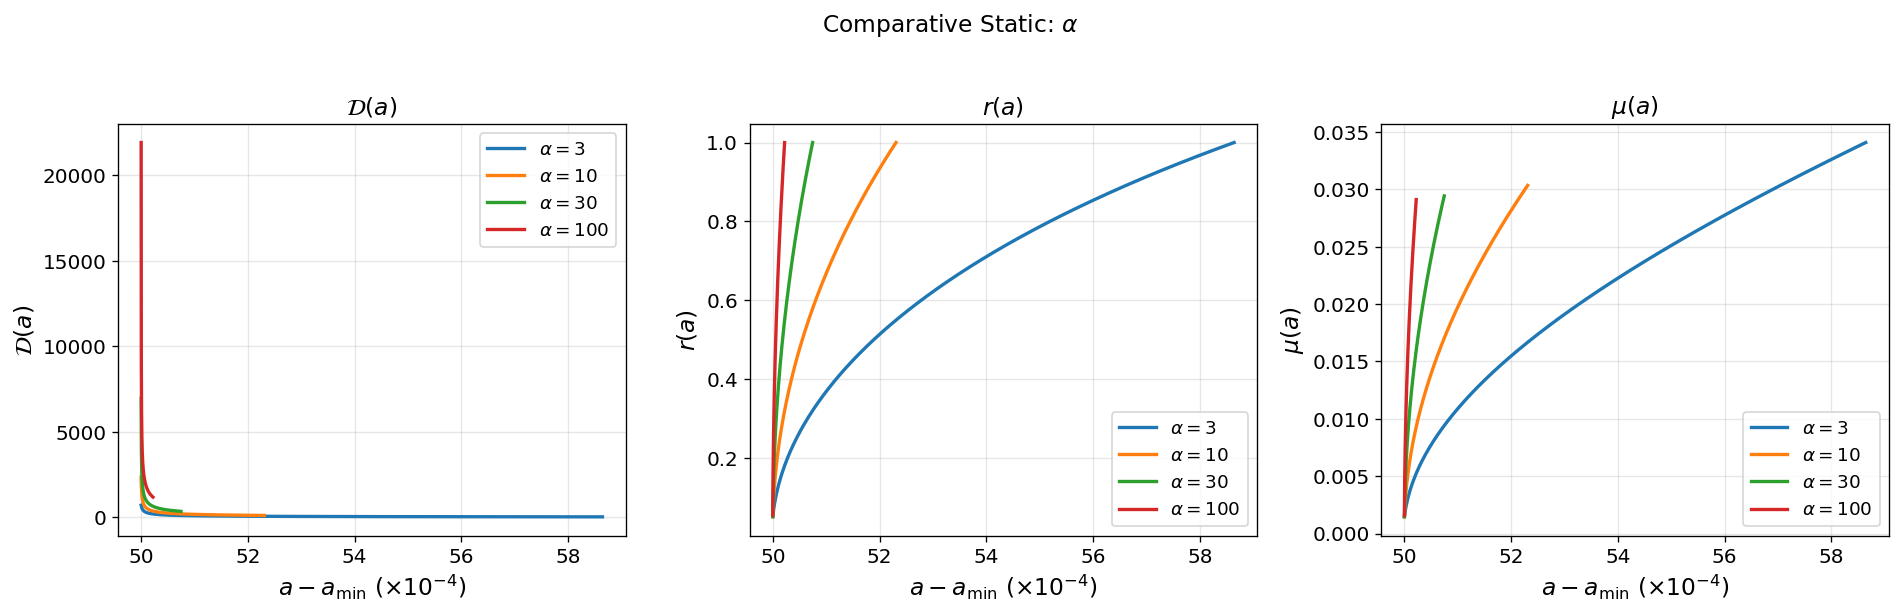

In [7]:
# === CS2: Buyer arrival rate alpha ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for alpha_val in [3, 10, 30, 100]:
    res = compute_lob(alpha_val, c, eta, N_LP, r_min, r_max)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'],  label=rf'$\alpha={alpha_val}$')
    axes[1].plot(sig*1e4, res['r'],  label=rf'$\alpha={alpha_val}$')
    axes[2].plot(sig*1e4, res['mu'], label=rf'$\alpha={alpha_val}$')

for i, (t, y) in enumerate([
    (r'$\mathcal{D}(a)$', r'$\mathcal{D}(a)$'),
    (r'$r(a)$', r'$r(a)$'), (r'$\mu(a)$', r'$\mu(a)$')]):
    axes[i].set_title(t); axes[i].set_ylabel(y)
    axes[i].set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $\alpha$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

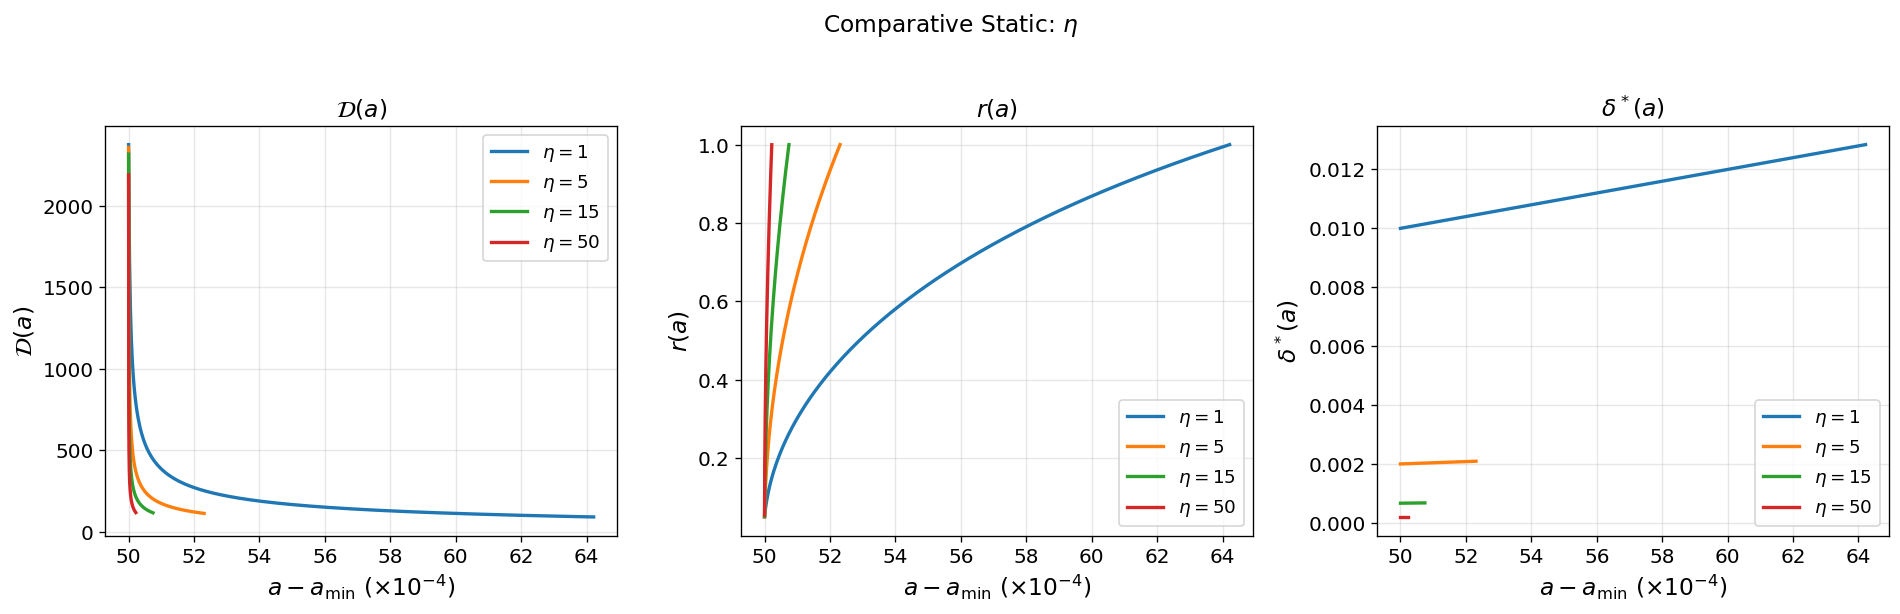

In [8]:
# === CS3: Carrying cost eta ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for eta_val in [1, 5, 15, 50]:
    res = compute_lob(alpha, c, eta_val, N_LP, r_min, r_max)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'],     label=rf'$\eta={eta_val}$')
    axes[1].plot(sig*1e4, res['r'],     label=rf'$\eta={eta_val}$')
    axes[2].plot(sig*1e4, res['delta'], label=rf'$\eta={eta_val}$')

for i, (t, y) in enumerate([
    (r'$\mathcal{D}(a)$', r'$\mathcal{D}(a)$'),
    (r'$r(a)$', r'$r(a)$'), (r'$\delta^*(a)$', r'$\delta^*(a)$')]):
    axes[i].set_title(t); axes[i].set_ylabel(y)
    axes[i].set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $\eta$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

c=0.10: a_min=0.550, width=1.36×10⁻⁴
c=0.30: a_min=0.650, width=2.31×10⁻⁴
c=0.50: a_min=0.750, width=4.80×10⁻⁴
c=0.70: a_min=0.850, width=16.88×10⁻⁴


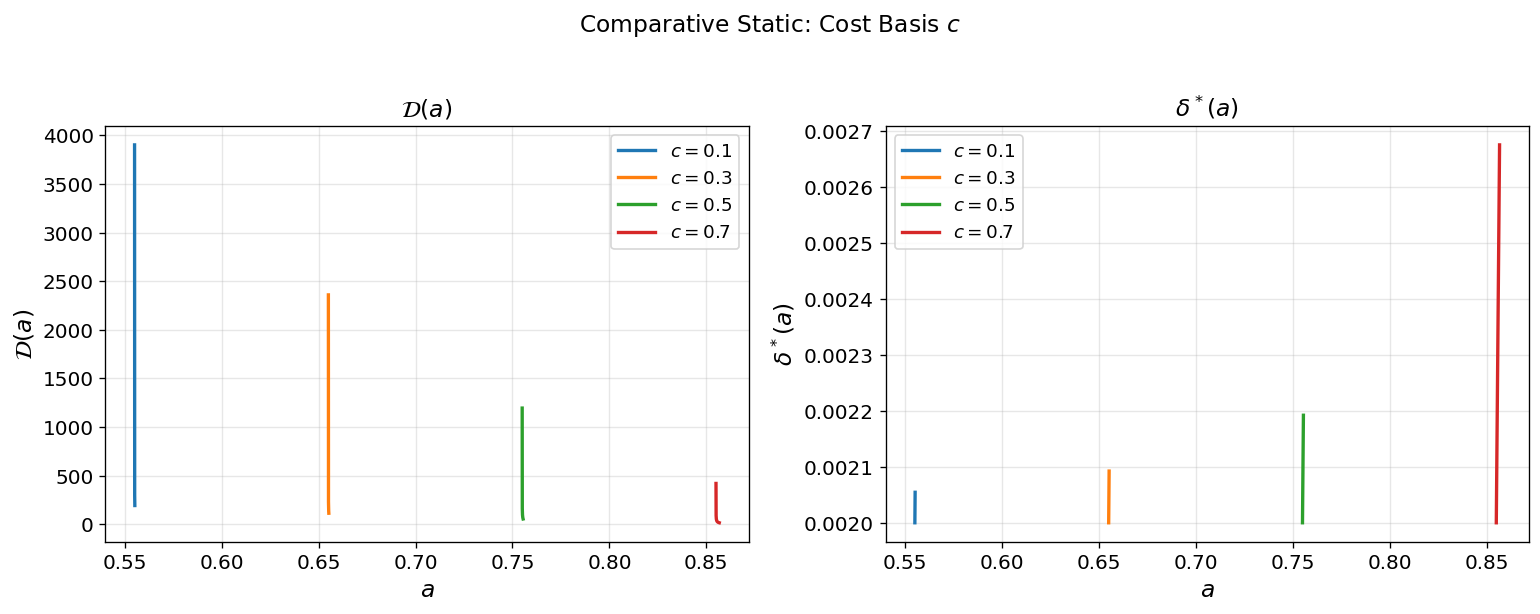

In [9]:
# === CS4: Cost basis c ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for c_val in [0.10, 0.30, 0.50, 0.70]:
    res = compute_lob(alpha, c_val, eta, N_LP, r_min, r_max)
    axes[0].plot(res['a'], res['D'],   label=f'$c={c_val}$')
    axes[1].plot(res['a'], res['delta'], label=f'$c={c_val}$')
    print(f'c={c_val:.2f}: a_min={res["a_min"]:.3f}, '
          f'width={res["book_width"]*1e4:.2f}×10⁻⁴')

axes[0].set_title(r'$\mathcal{D}(a)$'); axes[0].set_ylabel(r'$\mathcal{D}(a)$')
axes[1].set_title(r'$\delta^*(a)$'); axes[1].set_ylabel(r'$\delta^*(a)$')
for ax in axes:
    ax.set_xlabel('$a$'); ax.legend(); ax.grid(True, alpha=0.3)
fig.suptitle('Comparative Static: Cost Basis $c$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

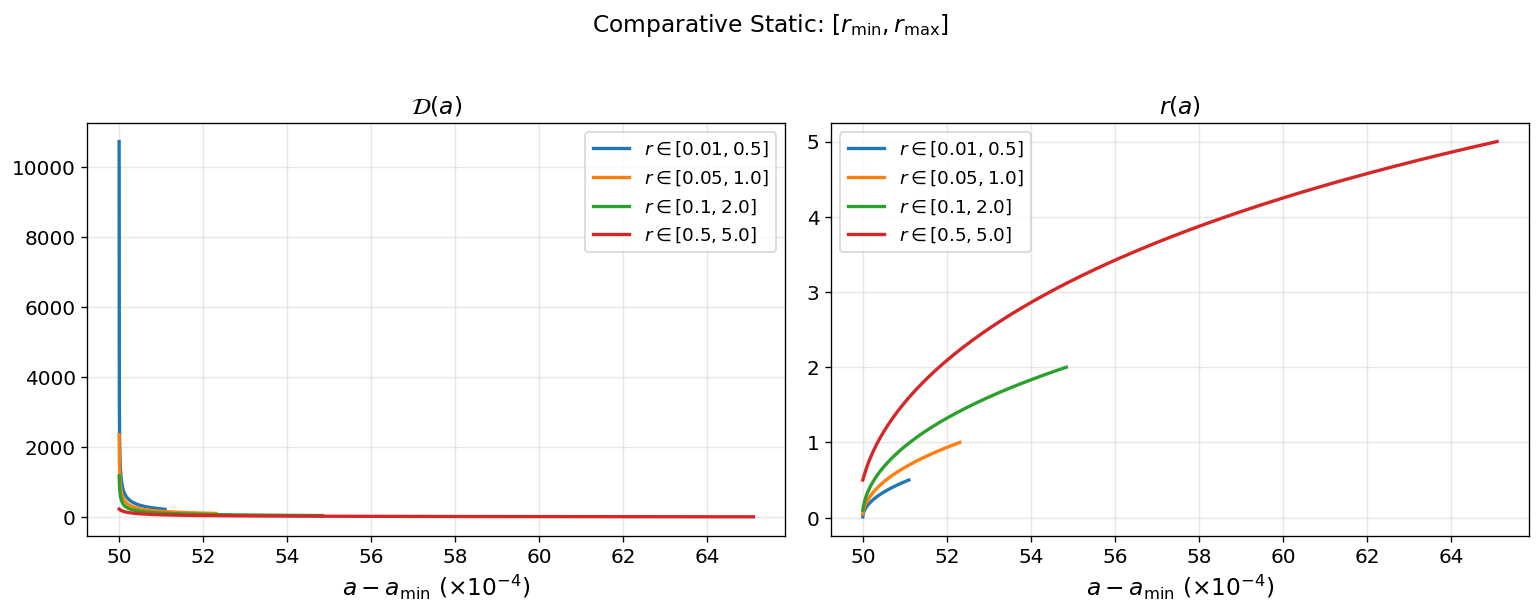

In [10]:
# === CS5: Discount rate range ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for rmin_v, rmax_v in [(0.01, 0.5), (0.05, 1.0), (0.1, 2.0), (0.5, 5.0)]:
    res = compute_lob(alpha, c, eta, N_LP, rmin_v, rmax_v)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'], label=f'$r\\in[{rmin_v},{rmax_v}]$')
    axes[1].plot(sig*1e4, res['r'], label=f'$r\\in[{rmin_v},{rmax_v}]$')

axes[0].set_title(r'$\mathcal{D}(a)$'); axes[1].set_title('$r(a)$')
for ax in axes:
    ax.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    ax.legend(); ax.grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $[r_{\min}, r_{\max}]$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 10. Total Depth Scaling and Price Impact

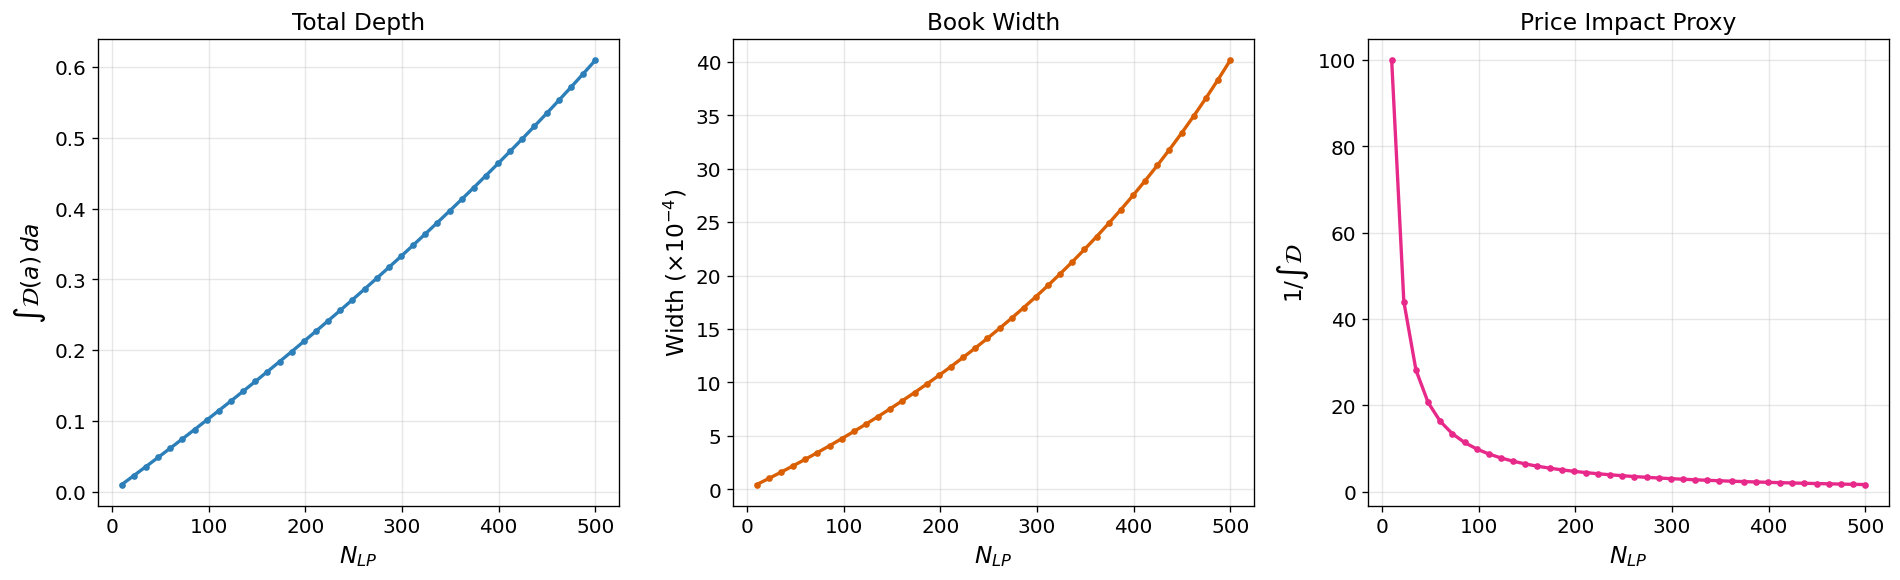

In [11]:
N_range = np.linspace(10, 500, 40)
total_depths, book_widths = [], []
for N_val in N_range:
    res = compute_lob(alpha, c, eta, N_val, r_min, r_max)
    total_depths.append(res['total_depth'])
    book_widths.append(res['book_width'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
ax1.plot(N_range, total_depths, 'o-', color='#2c7fb8', ms=3)
ax1.set_xlabel('$N_{LP}$'); ax1.set_ylabel(r'$\int \mathcal{D}(a)\, da$')
ax1.set_title('Total Depth'); ax1.grid(True, alpha=0.3)

ax2.plot(N_range, np.array(book_widths)*1e4, 'o-', color='#d95f02', ms=3)
ax2.set_xlabel('$N_{LP}$'); ax2.set_ylabel(r'Width ($\times 10^{-4}$)')
ax2.set_title('Book Width'); ax2.grid(True, alpha=0.3)

ax3.plot(N_range, 1.0/np.array(total_depths), 'o-', color='#e7298a', ms=3)
ax3.set_xlabel('$N_{LP}$'); ax3.set_ylabel(r'$1/\int\mathcal{D}$')
ax3.set_title('Price Impact Proxy'); ax3.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Extension: Pareto $G(r)$

Under Pareto: $g(r) = \beta\,r_{\min}^\beta\,r^{-(\beta+1)}$. The ODE generalises:
$$\mathcal{D}' = \frac{H'}{H}\mathcal{D} - \frac{2}{N_{LP}\,\delta^*\,g(H/\mathcal{D})\,H}\,\mathcal{D}^3$$
which we solve numerically.

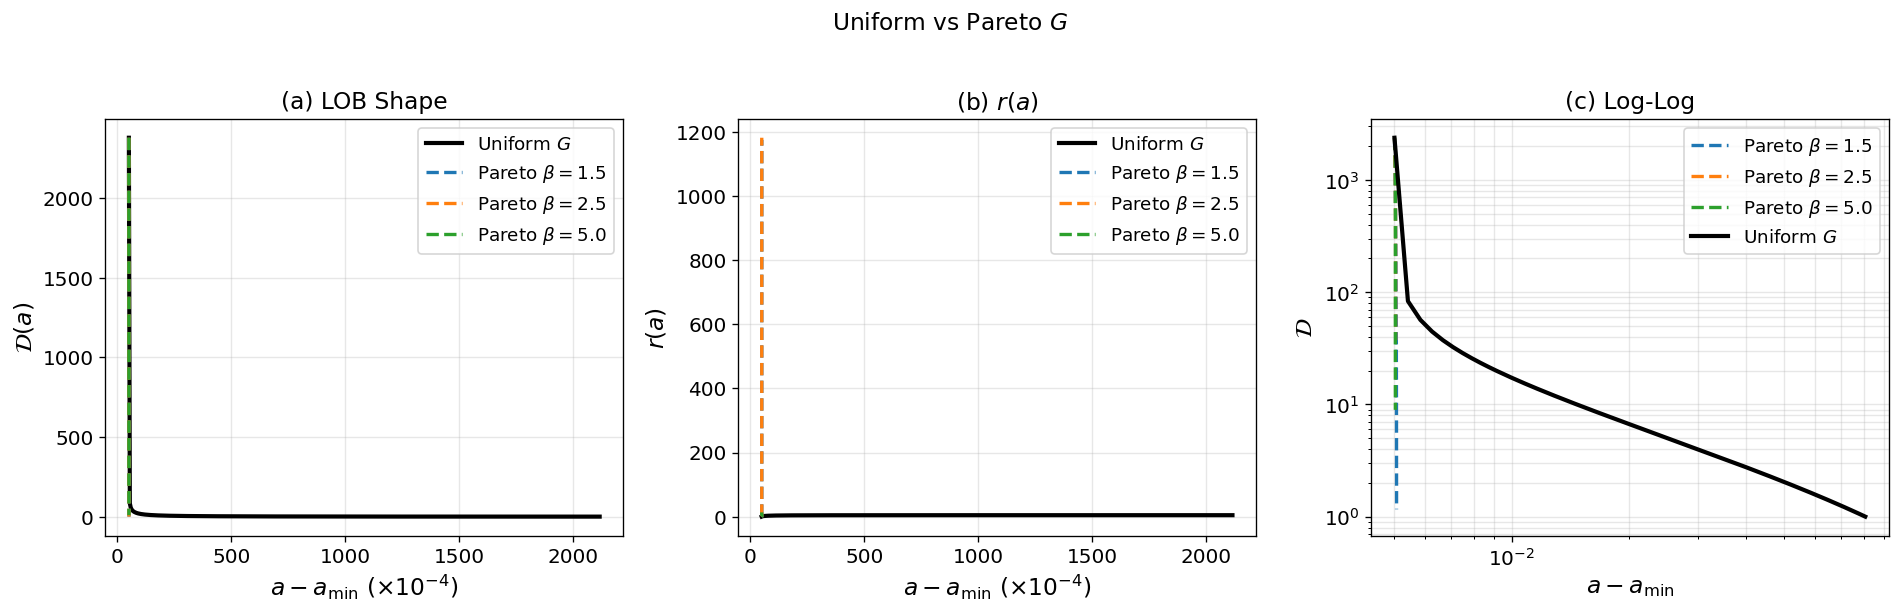

In [12]:
def solve_general_G(alpha_p, c_p, eta_p, N_LP_p, r_min_p, g_func,
                    eps_p=0.005, a_upper=0.98, n_pts=500):
    """Solve LOB ODE for general g(r)."""
    am = (1 + c_p) / 2
    a0_p = am + eps_p
    D0 = float(H_func(a0_p, alpha_p, c_p)) / r_min_p
    
    def rhs(a, D_vec):
        D = D_vec[0]
        if D < 1e-15: return [0.0]
        Hv = float(H_func(float(a), alpha_p, c_p))
        Hp = float(H_prime(float(a), alpha_p, c_p))
        ds = float(delta_star(float(a), c_p, eta_p))
        if ds < 1e-15: return [0.0]
        g_val = g_func(Hv / D)
        if g_val < 1e-20: return [0.0]
        return [(Hp/Hv)*D - 2.0/(N_LP_p*ds*g_val*Hv)*D**3]
    
    def d_small(a, D): return D[0] - 0.1
    d_small.terminal = True; d_small.direction = -1
    
    sol = solve_ivp(rhs, [a0_p, a_upper], [D0], method='DOP853',
                    dense_output=True, rtol=1e-10, atol=1e-12,
                    max_step=(a_upper-a0_p)/200, events=d_small)
    ag = np.linspace(a0_p, sol.t[-1], n_pts)
    Dv = np.maximum(sol.sol(ag)[0], 0)
    return ag, Dv, np.where(Dv>0, H_func(ag,alpha_p,c_p)/Dv, np.inf)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
a_u, D_u, r_u = solve_general_G(alpha, c, eta, N_LP, r_min, lambda r: 1.0/Delta_r)
sig_u = a_u - a_min
axes[0].plot(sig_u*1e4, D_u, 'k-', lw=2.5, label='Uniform $G$')
axes[1].plot(sig_u*1e4, r_u, 'k-', lw=2.5, label='Uniform $G$')

for beta_val in [1.5, 2.5, 5.0]:
    g_par = lambda r, b=beta_val: b * r_min**b * r**(-(b+1))
    a_p, D_p, r_p = solve_general_G(alpha, c, eta, N_LP, r_min, g_par)
    sig_p = a_p - a_min
    axes[0].plot(sig_p*1e4, D_p, '--', lw=2, label=rf'Pareto $\beta={beta_val}$')
    axes[1].plot(sig_p*1e4, r_p, '--', lw=2, label=rf'Pareto $\beta={beta_val}$')
    mask = (D_p > 1) & (sig_p > 0)
    if np.sum(mask) > 5:
        axes[2].loglog(sig_p[mask], D_p[mask], '--', lw=2, label=rf'Pareto $\beta={beta_val}$')

mask_u = (D_u > 1) & (sig_u > 0)
if np.sum(mask_u) > 5:
    axes[2].loglog(sig_u[mask_u], D_u[mask_u], 'k-', lw=2.5, label='Uniform $G$')

axes[0].set_title('(a) LOB Shape'); axes[0].set_ylabel(r'$\mathcal{D}(a)$')
axes[1].set_title('(b) $r(a)$'); axes[1].set_ylabel('$r(a)$')
axes[2].set_title('(c) Log-Log'); axes[2].set_ylabel(r'$\mathcal{D}$')
for i, ax in enumerate(axes):
    ax.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)' if i<2 else r'$a-a_{\min}$')
    ax.legend(); ax.grid(True, alpha=0.3, which='both')
fig.suptitle(r'Uniform vs Pareto $G$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## 12. Summary

### Closed-Form Result

Under uniform $F$ and $G$, the equilibrium LOB shape is:

$$\mathcal{D}(a) = \frac{\alpha(1-a)^2}{(2a-1-c)\sqrt{r_{\min}^2 + \frac{4\alpha\eta\Delta r}{N_{LP}}[J(a)-J(a_0)]}}$$

where $J(s) = \frac{1}{8}\bigl[-(1-c)^2/(2s-1-c) - 2(1-c)\ln(2s-1-c) + (2s-1-c)\bigr]$.

### Key Findings

1. **Bernoulli ODE**: The equilibrium equation reduces to a Bernoulli equation of order 3, solved exactly via $w = \mathcal{D}^{-2}$.

2. **Book concentration**: Under uniform distributions, the LOB concentrates near $a_{\min} = (1+c)/2$ — a structural prediction of the model.

3. **Monotone comparative statics**: $\mathcal{D}$ increases in $N_{LP}$ and $\alpha$; decreases in $\eta$ and $c$. Total depth scales linearly in $N_{LP}$.

4. **Pareto extension**: Heavy-tailed $G(r)$ generates wider, power-law LOB shapes.

### Comparative Statics Table

| Parameter | Effect on $\mathcal{D}$ | Intuition |
|-----------|------------------------|----------|
| $N_{LP} \uparrow$ | Deeper, wider book | More LPs $\Rightarrow$ more depth at every price |
| $\alpha \uparrow$ | Deeper book (through $H$) | More buyers $\Rightarrow$ higher fill value $\Rightarrow$ attracts depth |
| $\eta \uparrow$ | Shallower book | Higher carrying cost $\Rightarrow$ smaller $\delta^*$ |
| $c \uparrow$ | Book shifts right, thins | Higher cost basis $\Rightarrow$ LPs need wider spreads |

### Next Steps

1. Derive Pareto Bernoulli ODE solution analytically
2. Calibrate $G(r)$ to empirical Polymarket depth data
3. Add price impact layer for informational efficiency analysis
4. Extend to bid side for full spread